<a href="https://colab.research.google.com/github/Mazi-star/LABWORK1/blob/main/LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Создаем свой уникальный датасет
data = {
    'Товар': ['Смартфон', 'Ноутбук', 'Планшет', 'Смартфон', 'Наушники', 'Телевизор', 'Ноутбук', 'Монитор'],
    'Категория': ['Электроника', 'Компьютеры', 'Электроника', 'Электроника', 'Аудио', 'Электроника', 'Компьютеры', 'Компьютеры'],
    'Цена': [50000, 120000, 35000, 50000, 15000, 80000, 120000, np.nan],
    'Возраст_модели_мес': [12, 6, 18, 12, 3, 24, 6, 10],
    'Гарантия_мес': [24, 12, 12, 24, 6, 36, 12, 12]
}

df = pd.DataFrame(data)

print("Исходный DataFrame:")
display(df)



Исходный DataFrame:


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес
0,Смартфон,Электроника,50000.0,12,24
1,Ноутбук,Компьютеры,120000.0,6,12
2,Планшет,Электроника,35000.0,18,12
3,Смартфон,Электроника,50000.0,12,24
4,Наушники,Аудио,15000.0,3,6
5,Телевизор,Электроника,80000.0,24,36
6,Ноутбук,Компьютеры,120000.0,6,12
7,Монитор,Компьютеры,NaN,10,12


In [ ]:
print("--- Метод head(3) (Первые 3 строки) ---")
display(df.head(3))

print("\n--- Метод tail(2) (Последние 2 строки) ---")
display(df.tail(2))

print("\n--- Свойство shape (Размерность) ---")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

print("\n--- Метод info() (Типы данных и пропуски) ---")
df.info()

print("\n--- Метод describe() (Статистика числовых полей) ---")
display(df.describe())

--- Метод head(3) (Первые 3 строки) ---


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес
0,Смартфон,Электроника,50000.0,12,24
1,Ноутбук,Компьютеры,120000.0,6,12
2,Планшет,Электроника,35000.0,18,12



--- Метод tail(2) (Последние 2 строки) ---


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес
6,Ноутбук,Компьютеры,120000.0,6,12
7,Монитор,Компьютеры,NaN,10,12



--- Свойство shape (Размерность) ---
Строк: 8, Столбцов: 5

--- Метод info() (Типы данных и пропуски) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Товар               8 non-null      object 
 1   Категория           8 non-null      object 
 2   Цена                7 non-null      float64
 3   Возраст_модели_мес  8 non-null      int64  
 4   Гарантия_мес        8 non-null      int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 452.0+ bytes

--- Метод describe() (Статистика числовых полей) ---


,Цена,Возраст_модели_мес,Гарантия_мес
count,7.000000,8.00000,8.000000
mean,67142.857143,11.37500,17.250000
std,41013.934914,6.90626,9.852483
min,15000.000000,3.00000,6.000000
25%,42500.000000,6.00000,12.000000
50%,50000.000000,11.00000,12.000000
75%,100000.000000,13.50000,24.000000
max,120000.000000,24.00000,36.000000


In [ ]:
print("--- Расчет пропущенных значений (NaN) ---")
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

display(pd.DataFrame({'Кол-во NaN': missing_count, 'Процент %': missing_percent}))

# Логическое заполнение пропусков: заполняем пустую цену средней ценой компьютеров
df['Цена'] = df['Цена'].fillna(df.groupby('Категория')['Цена'].transform('mean'))

print("\n--- Удаление дубликатов строк ---")
rows_before = df.shape[0]
duplicates_count = df.duplicated().sum()

# Удаляем дубликаты
df_cleaned = df.drop_duplicates().reset_index(drop=True)
rows_after = df_cleaned.shape[0]

print(f"Количество строк до удаления: {rows_before}")
print(f"Найдено строк-дубликатов: {duplicates_count}")
print(f"Количество строк после удаления: {rows_after}")

print("\nОчищенный DataFrame:")
display(df_cleaned)

--- Расчет пропущенных значений (NaN) ---


,Кол-во NaN,Процент %
Цена,1,12.5
Товар,0,0.0
Категория,0,0.0
Возраст_модели_мес,0,0.0
Гарантия_мес,0,0.0



--- Удаление дубликатов строк ---
Количество строк до удаления: 8
Найдено строк-дубликатов: 2
Количество строк после удаления: 6

Очищенный DataFrame:


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес
0,Смартфон,Электроника,50000.0,12,24
1,Ноутбук,Компьютеры,120000.0,6,12
2,Планшет,Электроника,35000.0,18,12
3,Наушники,Аудио,15000.0,3,6
4,Телевизор,Электроника,80000.0,24,36
5,Монитор,Компьютеры,120000.0,10,12


In [ ]:
print("--- Фильтрация через query() (Цена > 40000) ---")
display(df_cleaned.query('Цена > 40000'))

print("\n--- Выборка через loc[] (Строки 0-2, столбцы 'Товар' и 'Цена') ---")
display(df_cleaned.loc[0:2, ['Товар', 'Цена']])

print("\n--- Выборка через iloc[] (Строки 0-2, столбцы 0-1) ---")
display(df_cleaned.iloc[0:3, 0:2])

print("\n--- Векторизованная работа с Datetime ---")
# Добавляем колонку с датами поставок (пока в виде строк)
df_cleaned['Дата_поставки'] = ['2025-01-15', '2025-11-20', '2024-06-10', '2026-02-01', '2025-08-14', '2023-12-25']

# Переводим в формат datetime
df_cleaned['Дата_поставки'] = pd.to_datetime(df_cleaned['Дата_поставки'])

# Считаем разницу в днях относительно сегодняшней даты
today = pd.to_datetime('today')
df_cleaned['Дней_с_момента_поставки'] = (today - df_cleaned['Дата_поставки']).dt.days

# Извлекаем отдельные составляющие даты в новые колонки
df_cleaned['Год'] = df_cleaned['Дата_поставки'].dt.year
df_cleaned['День'] = df_cleaned['Дата_поставки'].dt.day
df_cleaned['Месяц'] = df_cleaned['Дата_поставки'].dt.month

display(df_cleaned)

--- Фильтрация через query() (Цена > 40000) ---


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес
0,Смартфон,Электроника,50000.0,12,24
1,Ноутбук,Компьютеры,120000.0,6,12
4,Телевизор,Электроника,80000.0,24,36
5,Монитор,Компьютеры,120000.0,10,12



--- Выборка через loc[] (Строки 0-2, столбцы 'Товар' и 'Цена') ---


,Товар,Цена
0,Смартфон,50000.0
1,Ноутбук,120000.0
2,Планшет,35000.0



--- Выборка через iloc[] (Строки 0-2, столбцы 0-1) ---


,Товар,Категория
0,Смартфон,Электроника
1,Ноутбук,Компьютеры
2,Планшет,Электроника



--- Векторизованная работа с Datetime ---


,Товар,Категория,Цена,Возраст_модели_мес,Гарантия_мес,Дата_поставки,Дней_с_момента_поставки,Год,День,Месяц
0,Смартфон,Электроника,50000.0,12,24,2025-01-15,488,2025,15,1
1,Ноутбук,Компьютеры,120000.0,6,12,2025-11-20,179,2025,20,11
2,Планшет,Электроника,35000.0,18,12,2024-06-10,707,2024,10,6
3,Наушники,Аудио,15000.0,3,6,2026-02-01,106,2026,1,2
4,Телевизор,Электроника,80000.0,24,36,2025-08-14,277,2025,14,8
5,Монитор,Компьютеры,120000.0,10,12,2023-12-25,875,2023,25,12


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

При первичном анализе выявлены множественные пропущенные значения в признаках задержек (AIRLINE_DELAY, WEATHER_DELAY и др.). Данный феномен имеет строгое логическое объяснение: если рейс выполнен штатно и без опоздания, данные метрики не регистрируются и остаются пустыми. Следовательно, данные пропуски корректно интерпретировать как нулевые задержки и заполнить значением 0.

Исходный размер выборки: (50000, 31)
Размер выборки после приведения типов: (50000, 31)

Соотношение классов (0 - выполнен, 1 - отменен):
CANCELLED
0.0    98.604
1.0     1.396
Name: proportion, dtype: float64


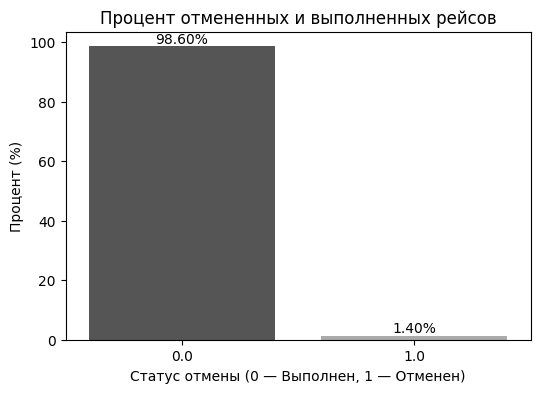


Топ-10 аэропортов по количеству отмен:
ORIGIN_AIRPORT
ORD    62.0
DFW    44.0
LGA    32.0
EWR    31.0
SFO    22.0
BOS    19.0
ATL    18.0
LAX    15.0
DEN    13.0
JFK    13.0
Name: CANCELLED, dtype: float64


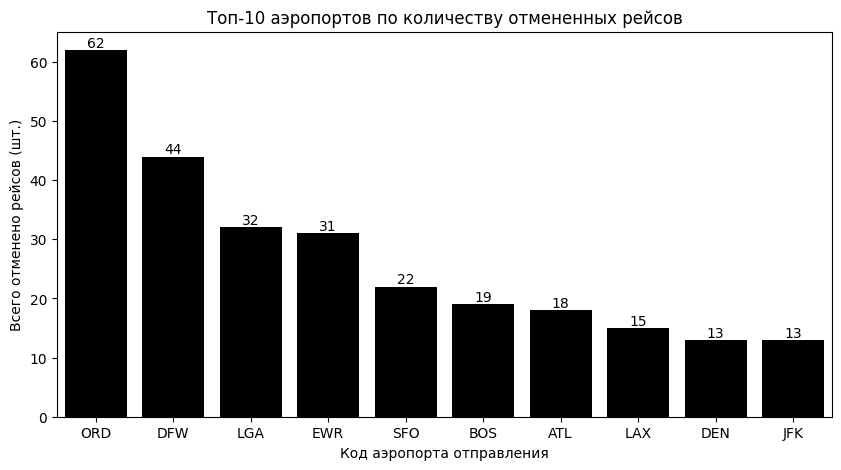


--- Анализ корреляции ---
Признак DAY_OF_WEEK: Пирсон = -0.0191 (p=0.0000), Спирмен = -0.0196 (p=0.0000)
Признак MONTH: Пирсон = -0.0492 (p=0.0000), Спирмен = -0.0472 (p=0.0000)


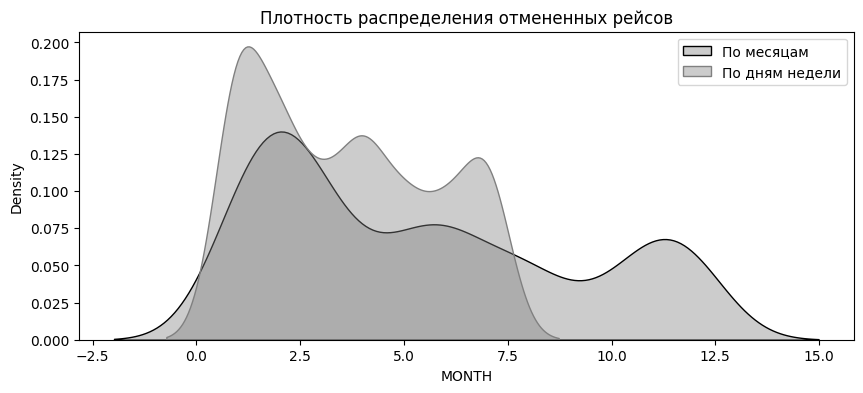


--- Статистика типов рейсов для UA, AA, DL ---


,CANCELLED,DIVERTED,NORMAL
AIRLINE,,,
AA,89.0,20.0,6252
DL,25.0,8.0,7559
UA,61.0,12.0,4304


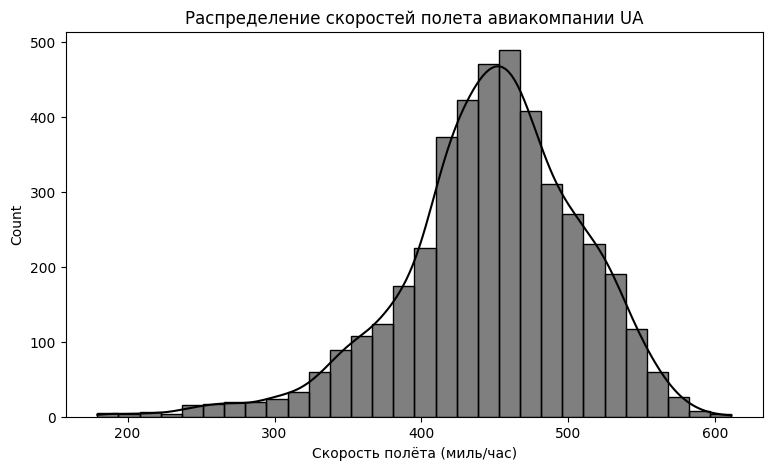

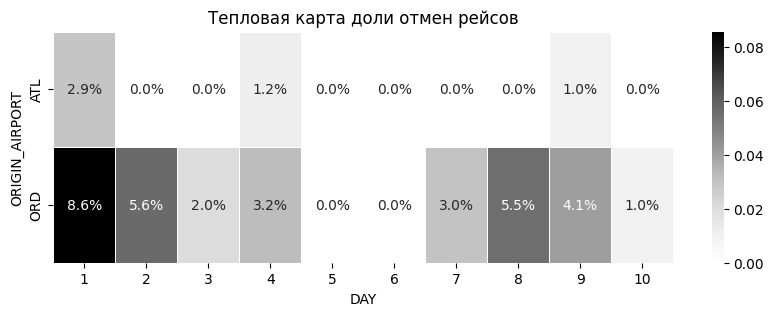


--- Топ-5 по задержкам прибытия ---


,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY
8,NK,15.634672,14.768854
5,F9,13.209738,11.714107
4,EV,8.972090,7.034184
2,B6,11.615827,6.655172
9,OO,8.598545,6.539721


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings

warnings.filterwarnings('ignore')


df_source = pd.read_csv('flights.csv', low_memory=False, on_bad_lines='skip')
df_flights = df_source.sample(n=50000, random_state=42).reset_index(drop=True)

print("Исходный размер выборки:", df_flights.shape)


numeric_columns = ['CANCELLED', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'DISTANCE', 'AIR_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DIVERTED']
for col in numeric_columns:
    if col in df_flights.columns:
        df_flights[col] = pd.to_numeric(df_flights[col], errors='coerce')

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
for col in delay_cols:
    if col in df_flights.columns:
        df_flights[col] = pd.to_numeric(df_flights[col], errors='coerce').fillna(0)

print("Размер выборки после приведения типов:", df_flights.shape)


if 'CANCELLED' in df_flights.columns:
    df_cancel_analysis = df_flights.dropna(subset=['CANCELLED'])

    cancel_percents = df_cancel_analysis['CANCELLED'].value_counts(normalize=True) * 100
    print("\nСоотношение классов (0 - выполнен, 1 - отменен):")
    print(cancel_percents)

    plt.figure(figsize=(6, 4))
    ax1 = sns.barplot(x=cancel_percents.index, y=cancel_percents.values, hue=cancel_percents.index, palette='gray', legend=False)
    plt.title('Процент отмененных и выполненных рейсов')
    plt.xlabel('Статус отмены (0 — Выполнен, 1 — Отменен)')
    plt.ylabel('Процент (%)')
    for p in ax1.patches:
        ax1.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

    top10_airports = df_cancel_analysis.groupby('ORIGIN_AIRPORT')['CANCELLED'].sum().sort_values(ascending=False).head(10)
    print("\nТоп-10 аэропортов по количеству отмен:")
    print(top10_airports)

    plt.figure(figsize=(10, 5))
    ax2 = sns.barplot(x=top10_airports.index, y=top10_airports.values, color='black')
    plt.title('Топ-10 аэропортов по количеству отмененных рейсов')
    plt.xlabel('Код аэропорта отправления')
    plt.ylabel('Всего отменено рейсов (шт.)')
    for p in ax2.patches:
        ax2.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

    print("\n--- Анализ корреляции ---")
    corr_data = df_cancel_analysis.dropna(subset=['DAY_OF_WEEK', 'MONTH'])
    for col in ['DAY_OF_WEEK', 'MONTH']:
        p_corr, p_val = pearsonr(corr_data[col], corr_data['CANCELLED'])
        s_corr, s_val = spearmanr(corr_data[col], corr_data['CANCELLED'])
        print(f"Признак {col}: Пирсон = {p_corr:.4f} (p={p_val:.4f}), Спирмен = {s_corr:.4f} (p={s_val:.4f})")

    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df_cancel_analysis[df_cancel_analysis['CANCELLED'] == 1], x='MONTH', label='По месяцам', color='black', fill=True, alpha=0.2)
    sns.kdeplot(data=df_cancel_analysis[df_cancel_analysis['CANCELLED'] == 1], x='DAY_OF_WEEK', label='По дням недели', color='gray', fill=True, alpha=0.4)
    plt.title('Плотность распределения отмененных рейсов')
    plt.legend()
    plt.show()

    df_3 = df_cancel_analysis[df_cancel_analysis['AIRLINE'].isin(['UA', 'AA', 'DL'])].copy()
    df_3['NORMAL'] = ((df_3['CANCELLED'] == 0) & (df_3['DIVERTED'] == 0)).astype(int)
    print("\n--- Статистика типов рейсов для UA, AA, DL ---")
    display(df_3.groupby('AIRLINE').agg({'CANCELLED': 'sum', 'DIVERTED': 'sum', 'NORMAL': 'sum'}))

    df_speed = df_flights.dropna(subset=['AIR_TIME', 'DISTANCE'])
    df_speed = df_speed[df_speed['AIR_TIME'] > 0]
    df_speed['SPEED'] = df_speed['DISTANCE'] / (df_speed['AIR_TIME'] / 60)

    plt.figure(figsize=(9, 5))
    sns.histplot(data=df_speed[df_speed['AIRLINE'] == 'UA'], x='SPEED', kde=True, color='black', bins=30)
    plt.title('Распределение скоростей полета авиакомпании UA')
    plt.xlabel('Скорость полёта (миль/час)')
    plt.show()

    df_pivot = df_cancel_analysis[(df_cancel_analysis['ORIGIN_AIRPORT'].isin(['ATL', 'ORD'])) & (df_cancel_analysis['DAY'] <= 10)]
    pivot_table = df_pivot.pivot_table(index='ORIGIN_AIRPORT', columns='DAY', values='CANCELLED', aggfunc='mean')
    plt.figure(figsize=(10, 3))
    sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap='Greys', linewidths=.5)
    plt.title('Тепловая карта доли отмен рейсов')
    plt.show()


df_delays = df_flights.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])
df_delays_grouped = df_delays.groupby('AIRLINE').agg({'DEPARTURE_DELAY': 'mean', 'ARRIVAL_DELAY': 'mean'}).reset_index()
print("\n--- Топ-5 по задержкам прибытия ---")
display(df_delays_grouped.sort_values(by='ARRIVAL_DELAY', ascending=False).head(5))